In [3]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path
from sklearn.linear_model import LinearRegression

sys.path.append(str(Path.cwd().parent))

from src.data.features.build_features import add_lagged_returns, add_log_returns, add_log_rolling_volatility, add_rolling_z_score, add_rsi, load_prices_long
from src.data.targets.build_targets import add_volatility_target, add_direction_target
from src.models.evaluation import evaluate_predictions, walk_forward_folds, run_walk_forward

In [4]:
tickers = ['SPY','GOOG', 'NVDA', 'NFLX', 'MSFT']
df = load_prices_long("../data/raw_prices.parquet", tickers)
df.head()

Price,date,open,high,low,close,volume,ticker
0,2020-01-02,294.912997,296.143553,293.992353,296.125305,59151200,SPY
1,2020-01-03,292.743535,295.004113,292.688847,293.882935,77709700,SPY
2,2020-01-06,292.132782,295.086123,292.014280,295.004089,55653900,SPY
3,2020-01-07,294.438973,294.912981,293.727989,294.174652,40496400,SPY
4,2020-01-08,294.366059,296.954771,294.119959,295.742462,68296000,SPY


In [5]:
df = add_log_returns(df)
df = add_log_rolling_volatility(df, [5, 10, 20])
df = add_rsi(df, [14])
df = add_volatility_target(df, [5])
df.head()

Price,date,open,high,low,close,volume,ticker,log_return,vol_5d,vol_10d,vol_20d,rsi_14d,target_vol_5d
1648,2020-01-02,66.491263,67.809142,66.491263,67.770981,28132000,GOOG,NaN,NaN,NaN,NaN,NaN,-1.712450
1649,2020-01-03,66.803994,68.025229,66.689207,67.438400,23728000,GOOG,-0.004919,NaN,NaN,NaN,0.000000,-1.930775
1650,2020-01-06,66.910074,69.214751,66.910074,69.101257,34646000,GOOG,0.024358,NaN,NaN,NaN,84.336986,-2.692365
1651,2020-01-07,69.286129,69.536417,68.911427,69.058136,30054000,GOOG,-0.000624,NaN,NaN,NaN,82.396332,-2.277503
1652,2020-01-08,68.995682,69.962167,68.934228,69.602341,30560000,GOOG,0.007849,NaN,NaN,NaN,86.590143,-2.299001


In [6]:
eval_metrics = evaluate_predictions(df["target_vol_5d"], df["vol_5d"])
eval_metrics

RMSE    0.658135
MAE     0.511765
dtype: float64

<Axes: xlabel='test_start'>

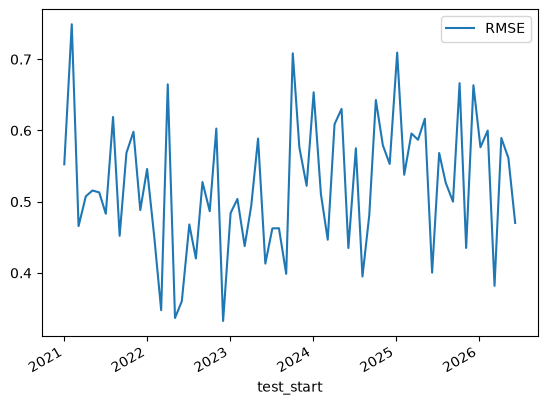

In [7]:
feature_cols = ['vol_5d', 'vol_10d', 'vol_20d', 'rsi_14d']  # whatever you've settled on
target_col = 'target_vol_5d'

results = run_walk_forward(
    df, feature_cols, target_col,
    model_factory=lambda: LinearRegression(),
    train_size=252, test_size=21,
)

results[['RMSE', 'MAE']].mean()  
results.plot(x='test_start', y='RMSE')